In [4]:
from lib.lib_coulomb import (
        read_xyz,
        calculate_coulomb_matrix,
        compute_eigenvalues,
        sort_by_row_norm,
        padd_matrix
    )
from pathlib import Path
from tqdm import tqdm
import shutil
import numpy as np
import json
import seaborn as sns
import math
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_paper/Coulomb_G/training_dataset")
# xyz_path = Path("/home/tommaso/xyz_files_G")

# for dir in ["train","test","val"]:
#     samples = [f for f in dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
#     for sample in tqdm(samples):
#         atomic_numbers, coordinates = read_xyz(xyz_path.joinpath(f"{sample.stem}.xyz"))
#         m = calculate_coulomb_matrix(atomic_numbers, coordinates)
#         np.save(dataset.joinpath(dir,f"{sample.stem}.npy"),m)

100%|██████████| 1050/1050 [00:19<00:00, 53.08it/s]


In [7]:
source_dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_paper/Coulomb_GO/training_dataset")
dest_dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_paper/Coulomb_GO/subset_training_dataset_2000")
dest_dataset.joinpath("train").mkdir(exist_ok=True,parents=True)
dest_dataset.joinpath("test").mkdir(exist_ok=True,parents=True)
dest_dataset.joinpath("val").mkdir(exist_ok=True,parents=True)
xyz_path = Path("/home/tommaso/xyz_files_GO")
threshold_min = 1500
threshold_max = 2000

for dir in ["train","test","val"]:
    txt_files = [f for f in source_dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    shutil.copy(source_dataset.joinpath(dir,f"{dir}.csv"),dest_dataset.joinpath(dir,f"{dir}.csv"))
    for file in tqdm(txt_files):
        num_atoms = np.loadtxt(file)
        if np.sum(num_atoms)>threshold_min and np.sum(num_atoms)<threshold_max:
            shutil.copy(file,dest_dataset.joinpath(dir,f"{file.stem}.txt"))

shutil.copy(source_dataset.joinpath("dataset.csv"),dest_dataset.joinpath("dataset.csv"))

for dir in ["train","test","val"]:
    samples = [f for f in dest_dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    for sample in tqdm(samples):
        atomic_numbers, coordinates = read_xyz(xyz_path.joinpath(f"{sample.stem}.xyz"))
        m = calculate_coulomb_matrix(atomic_numbers, coordinates)
        np.save(dest_dataset.joinpath(dir,f"{sample.stem}.npy"),m)

100%|██████████| 38/38 [00:18<00:00,  2.07it/s]


In [7]:
dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_paper/Coulomb_GO/subset_training_dataset_2000")
max_num_atoms = 0
samples = {}

for dir in ["train","test","val"]:
    txt_files = [f for f in dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    samples[dir] = len(txt_files)
    for file in tqdm(txt_files):
        num_atoms = np.loadtxt(file)
        if np.sum(num_atoms)>max_num_atoms:
            max_num_atoms = np.sum(num_atoms)

print(max_num_atoms)
np.savetxt(dataset.joinpath("max_num_atoms.txt"),np.array([max_num_atoms]))
with open(str(dataset.joinpath("num_samples.yaml")),"w") as f:
    json.dump(samples,f,indent=4)

100%|██████████| 38/38 [00:00<00:00, 9610.68it/s]

1949.0


100%|██████████| 19447/19447 [00:00<00:00, 58353.37it/s]
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


191


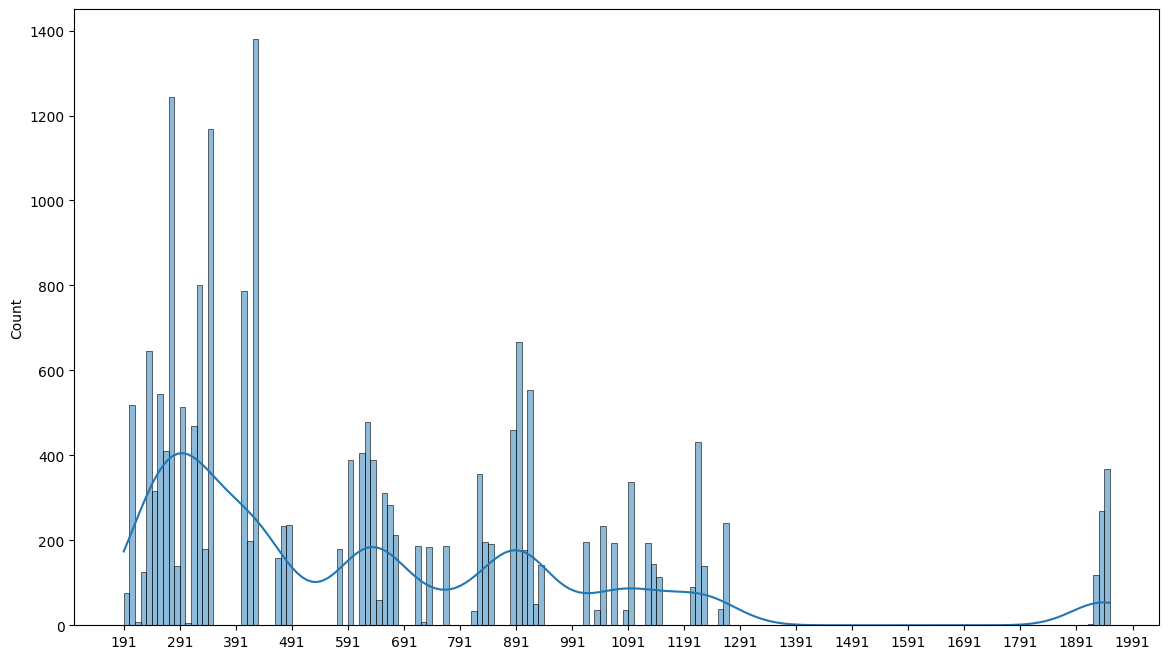

In [18]:
xyz_path = Path("/home/tommaso/xyz_files_GO")
num_atoms = []

def estrai_numero_atomi(file_path: Path):
    try:
        with open(str(file_path), 'r') as file:
            # Legge la prima riga e la converte in un intero
            numero_atomi = int(file.readline().strip())
            return numero_atomi
    except FileNotFoundError:
        print(f"Errore: il file {file_path} non è stato trovato.")
    except ValueError:
        print(f"Errore: il contenuto del file {file_path} non è valido.")
        
samples = [f for f in xyz_path.iterdir() if f.suffix.lower() ==".xyz"]
for sample in tqdm(samples):
    num_atoms.append(estrai_numero_atomi(sample))

plt.figure(figsize=(14, 8))
sns.histplot(num_atoms,kde=True, binwidth=10)
plt.xticks(np.arange(min(num_atoms), max(num_atoms) + 100, 100))
plt.show
print(min(num_atoms))

3174


/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


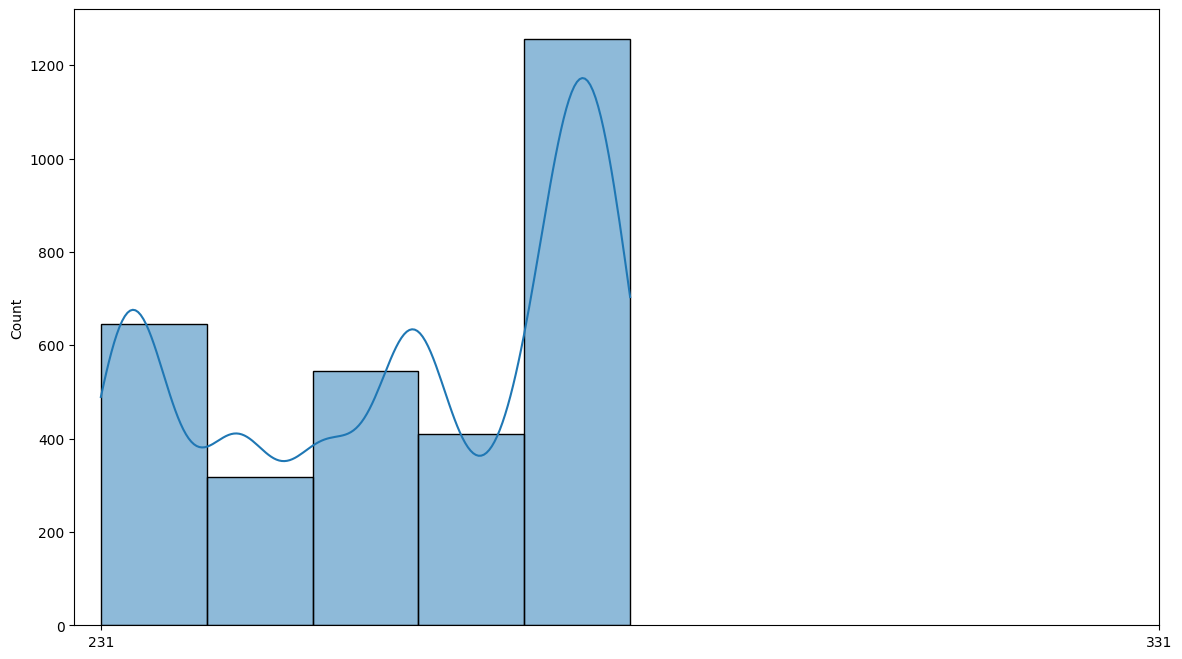

In [20]:
sottolista = [x for x in num_atoms if 231 <= x <= 281]
plt.figure(figsize=(14, 8))
sns.histplot(sottolista,kde=True, binwidth=10)
plt.xticks(np.arange(min(sottolista), max(sottolista) + 100, 100))
plt.show
print(len(sottolista))

Coulomb clusters

/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


210


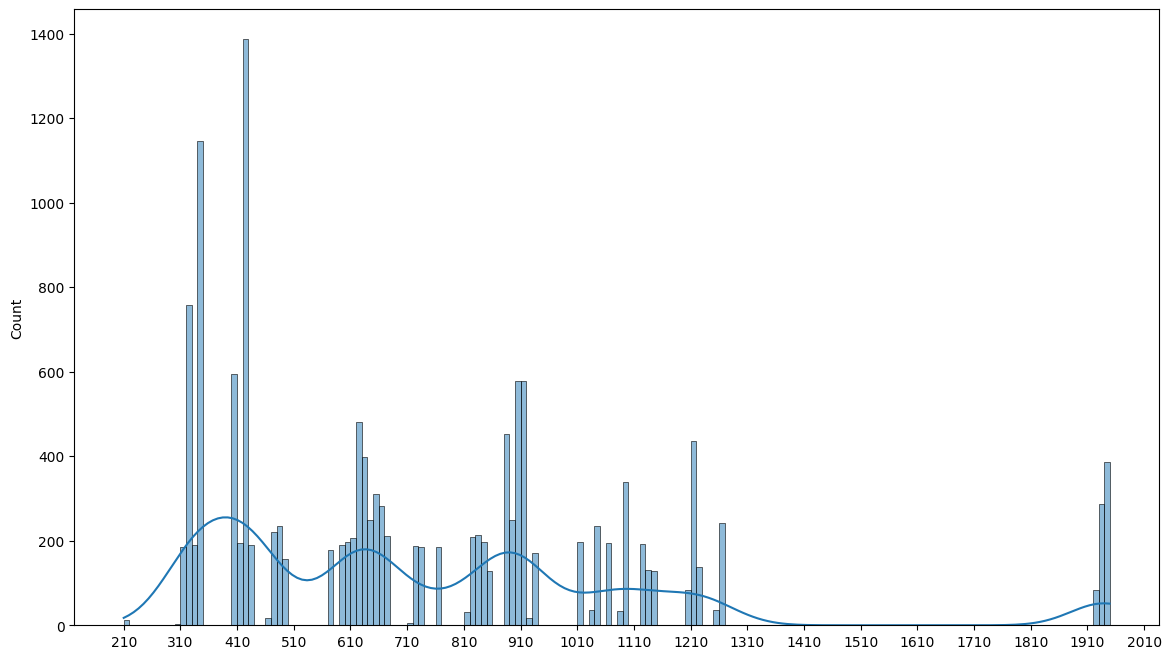

In [5]:
xyz_path = Path("/home/tommaso/xyz_files_GO")
df = pd.read_csv(xyz_path.joinpath("dataset_with_formation_energy.csv"))
df = df[df["distribution_mean"] > 0.2]
num_atoms = df["atom_number_total"].values

plt.figure(figsize=(14, 8))
sns.histplot(num_atoms,kde=True, binwidth=10)
plt.xticks(np.arange(min(num_atoms), max(num_atoms) + 100, 100))
plt.show
print(min(num_atoms))

2278


/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


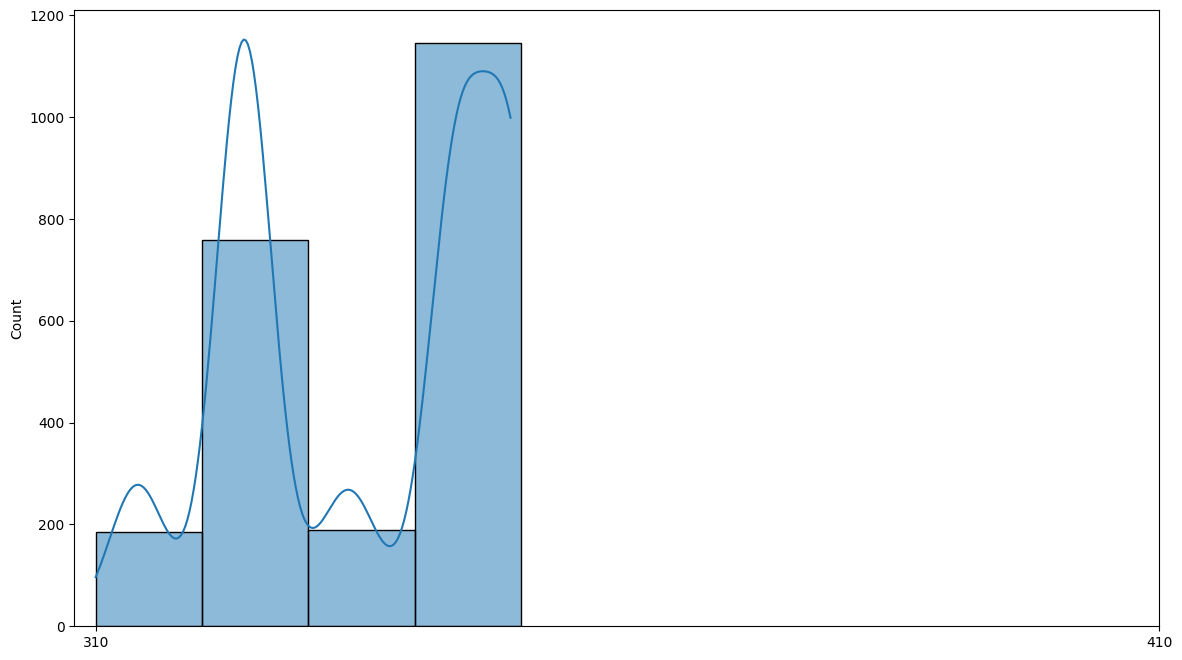

In [25]:
sottolista = [x for x in num_atoms if 310 <= x <= 350]
plt.figure(figsize=(14, 8))
sns.histplot(sottolista,kde=True, binwidth=10)
plt.xticks(np.arange(min(sottolista), max(sottolista) + 100, 100))
plt.show
print(len(sottolista))

In [26]:
dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_paper/cluster_Coulomb_GO/training_dataset")
xyz_path = Path("/home/tommaso/xyz_files_GO")

for dir in ["train","test","val"]:
    samples = [f for f in dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    for sample in tqdm(samples):
        atomic_numbers, coordinates = read_xyz(xyz_path.joinpath(f"{sample.stem}.xyz"))
        m = calculate_coulomb_matrix(atomic_numbers, coordinates)
        np.save(dataset.joinpath(dir,f"{sample.stem}.npy"),m)

100%|██████████| 342/342 [00:05<00:00, 66.67it/s]


1579


/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


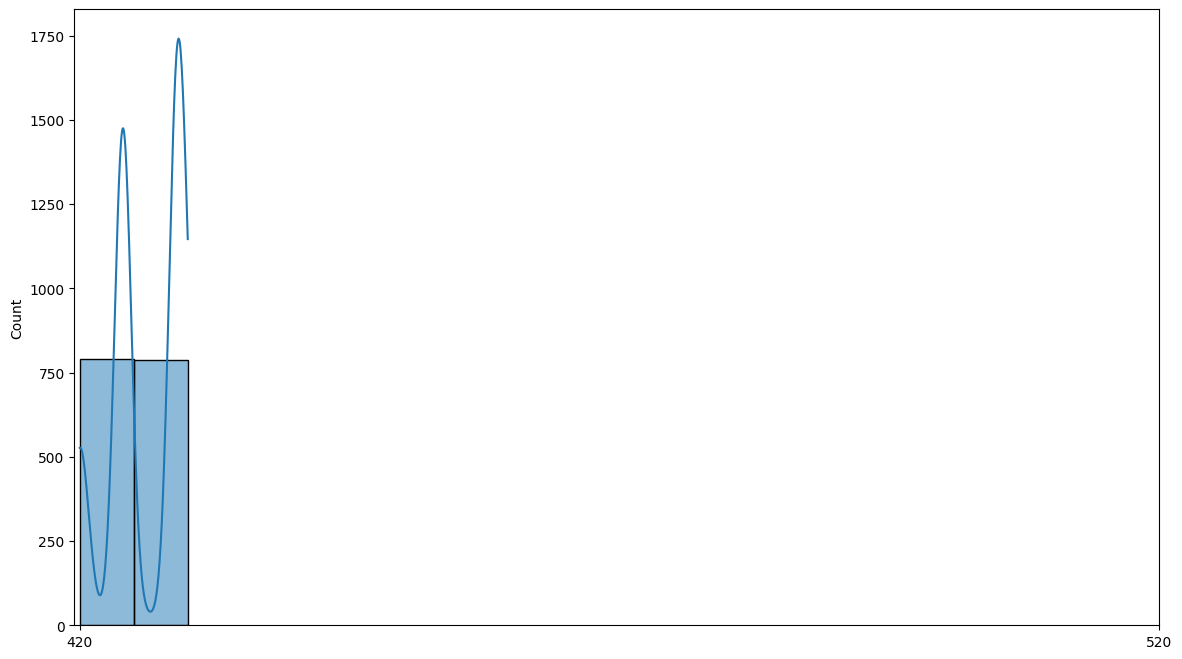

In [7]:
sottolista = [x for x in num_atoms if 420 <= x <= 430]
plt.figure(figsize=(14, 8))
sns.histplot(sottolista,kde=True, binwidth=5)
plt.xticks(np.arange(min(sottolista), max(sottolista) + 100, 100))
plt.show
print(len(sottolista))

In [8]:
dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_paper/cluster_420-430_Coulomb_GO/training_dataset")
xyz_path = Path("/home/tommaso/xyz_files_GO")

for dir in ["train","test","val"]:
    samples = [f for f in dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    for sample in tqdm(samples):
        atomic_numbers, coordinates = read_xyz(xyz_path.joinpath(f"{sample.stem}.xyz"))
        m = calculate_coulomb_matrix(atomic_numbers, coordinates)
        np.save(dataset.joinpath(dir,f"{sample.stem}.npy"),m)

100%|██████████| 237/237 [00:05<00:00, 40.87it/s]


1643


/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


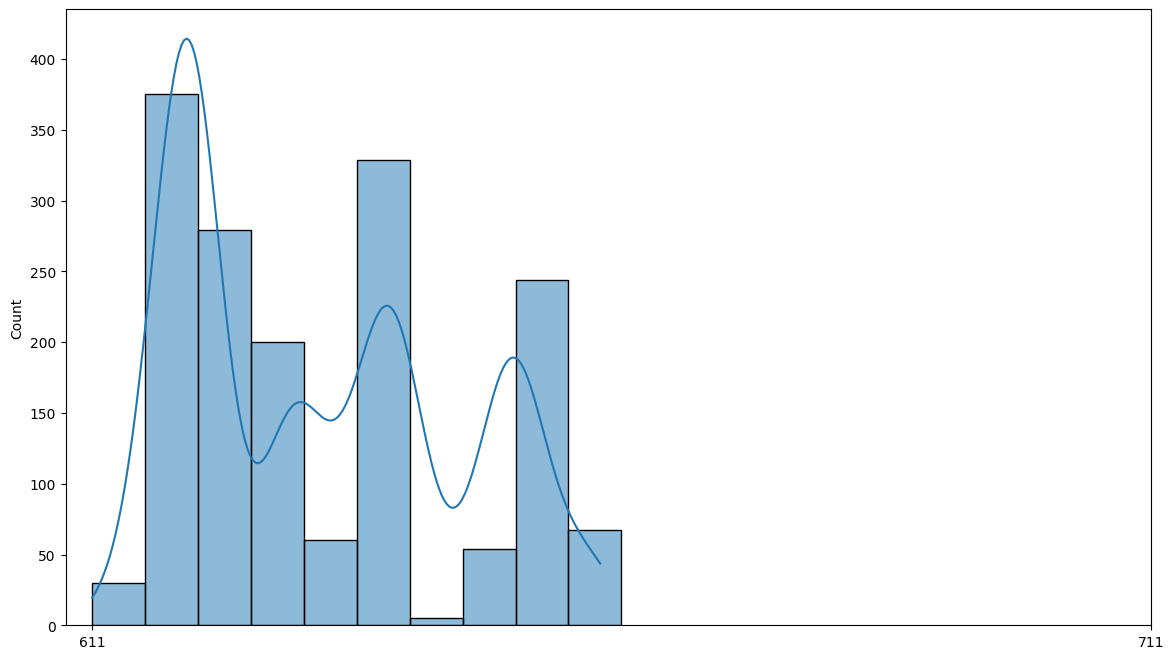

In [9]:
sottolista = [x for x in num_atoms if 610 <= x <= 660]
plt.figure(figsize=(14, 8))
sns.histplot(sottolista,kde=True, binwidth=5)
plt.xticks(np.arange(min(sottolista), max(sottolista) + 100, 100))
plt.show
print(len(sottolista))

In [5]:
dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_paper/cluster_310-350_Coulomb_GO/training_dataset")
xyz_path = Path("/home/tommaso/xyz_files_GO")

for dir in ["train","test","val"]:
    samples = [f for f in dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    for sample in tqdm(samples):
        atomic_numbers, coordinates = read_xyz(xyz_path.joinpath(f"{sample.stem}.xyz"))
        m = calculate_coulomb_matrix(atomic_numbers, coordinates)
        np.save(dataset.joinpath(dir,f"{sample.stem}.npy"),m)

100%|██████████| 342/342 [00:05<00:00, 65.52it/s]


In [6]:
dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_paper/cluster_610-660_Coulomb_GO/training_dataset")
xyz_path = Path("/home/tommaso/xyz_files_GO")

for dir in ["train","test","val"]:
    samples = [f for f in dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    for sample in tqdm(samples):
        atomic_numbers, coordinates = read_xyz(xyz_path.joinpath(f"{sample.stem}.xyz"))
        m = calculate_coulomb_matrix(atomic_numbers, coordinates)
        np.save(dataset.joinpath(dir,f"{sample.stem}.npy"),m)

100%|██████████| 246/246 [00:13<00:00, 18.73it/s]


In [2]:
dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_paper/cluster_310-660_Coulomb_GO/training_dataset")
xyz_path = Path("/home/tommaso/xyz_files_GO")

for dir in ["train","test","val"]:
    samples = [f for f in dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    for sample in tqdm(samples):
        atomic_numbers, coordinates = read_xyz(xyz_path.joinpath(f"{sample.stem}.xyz"))
        m = calculate_coulomb_matrix(atomic_numbers, coordinates)
        np.save(dataset.joinpath(dir,f"{sample.stem}.npy"),m)

100%|██████████| 1123/1123 [00:33<00:00, 33.90it/s]


In [3]:
dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_final/Coulomb_GO/training_dataset_reference")
xyz_path = Path("/home/tommaso/xyz_files_GO")

for dir in ["train","test","val"]:
    samples = [f for f in dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    for sample in tqdm(samples):
        atomic_numbers, coordinates = read_xyz(xyz_path.joinpath(f"{sample.stem}.xyz"))
        m = calculate_coulomb_matrix(atomic_numbers, coordinates)
        np.save(dataset.joinpath(dir,f"{sample.stem}.npy"),m)

  0%|          | 0/4899 [00:00<?, ?it/s]

100%|██████████| 1050/1050 [01:23<00:00, 12.52it/s]


Eigen Dataset

In [6]:
dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_final/Coulomb_GO/eigen_cluster_310-660/training_dataset")
xyz_path = Path("/home/tommaso/xyz_files_GO")
resolution =660

for dir in ["train","test","val"]:
    samples = [f for f in dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    for sample in tqdm(samples):
        atomic_numbers, coordinates = read_xyz(xyz_path.joinpath(f"{sample.stem}.xyz"))
        coulomb = calculate_coulomb_matrix(atomic_numbers, coordinates)
        coulomb = sort_by_row_norm(coulomb)
        #coulomb = padd_matrix(coulomb, resolution)
        coulomb = compute_eigenvalues(coulomb)
        #coulomb = (coulomb - np.min(coulomb)) / (np.max(coulomb) - np.min(coulomb))
        coulomb = coulomb.flatten()
        np.save(dataset.joinpath(dir,f"{sample.stem}.npy"),coulomb)

100%|██████████| 1123/1123 [04:13<00:00,  4.43it/s]


In [2]:
dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_final/Coulomb_GO/eigen_training_dataset_reference")
xyz_path = Path("/home/tommaso/xyz_files_GO")
resolution =1950

for dir in ["train","test","val"]:
    samples = [f for f in dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    for sample in tqdm(samples):
        atomic_numbers, coordinates = read_xyz(xyz_path.joinpath(f"{sample.stem}.xyz"))
        m = calculate_coulomb_matrix(atomic_numbers, coordinates)
        coulomb = sort_by_row_norm(m)
        #coulomb = padd_matrix(coulomb, resolution)
        coulomb = compute_eigenvalues(m)
        #coulomb = (coulomb - np.min(coulomb)) / (np.max(coulomb) - np.min(coulomb))
        coulomb = coulomb.flatten()
        np.save(dataset.joinpath(dir,f"{sample.stem}.npy"),coulomb)

  0%|          | 0/4899 [00:00<?, ?it/s]

100%|██████████| 1050/1050 [08:38<00:00,  2.02it/s]


In [4]:
dataset = Path("/home/tommaso/git_workspace/GrapheNet/data_final/Coulomb_GO/cluster_1000-2000/training_dataset")
xyz_path = Path("/home/tommaso/xyz_files_GO")
resolution =1950

for dir in ["train","test","val"]:
    samples = [f for f in dataset.joinpath(dir).iterdir() if f.suffix.lower() ==".txt"]
    for sample in tqdm(samples):
        atomic_numbers, coordinates = read_xyz(xyz_path.joinpath(f"{sample.stem}.xyz"))
        m = calculate_coulomb_matrix(atomic_numbers, coordinates)
        coulomb = sort_by_row_norm(m)
        #coulomb = padd_matrix(coulomb, resolution)
        coulomb = compute_eigenvalues(m)
        #coulomb = (coulomb - np.min(coulomb)) / (np.max(coulomb) - np.min(coulomb))
        coulomb = coulomb.flatten()
        np.save(dataset.joinpath(dir,f"{sample.stem}.npy"),coulomb)

100%|██████████| 477/477 [10:41<00:00,  1.35s/it]


# TEST

In [13]:
import torch

m = np.load("/home/tommaso/git_workspace/GrapheNet/data_final/Coulomb_GO/eigen_cluster_310-660/training_dataset/train/neutral_18855.npy")

k = torch.from_numpy(m.copy()).float()

print(k.shape)
print(len(m.shape))

torch.Size([404])
1


In [1]:
def convert_to_decimal(time_str):
    # Dividi la stringa del tempo in minuti e secondi
    minutes, seconds = map(int, time_str.split(':'))
    # Converti i secondi in frazione di minuto e somma ai minuti
    decimal_time = minutes + seconds / 60
    return decimal_time


print("cluster 310-350")
print(convert_to_decimal("0:14")) #img
print(convert_to_decimal("0:35")) #matrix

print("cluster 610-660")
print(convert_to_decimal("0:18")) #img
print(convert_to_decimal("2:27")) #matrix


print("cluster 310-660")
print(convert_to_decimal("1:05")) #img
print(convert_to_decimal("3:42")) #matrix
print(convert_to_decimal("29:15")) #eigen

print("cluster 1000-2000")
print(convert_to_decimal("1:54")) #img
print(convert_to_decimal("55:06")+convert_to_decimal("11:41")+convert_to_decimal("10:41")) #eigen

cluster 310-350
0.23333333333333334
0.5833333333333334
cluster 610-660
0.3
2.45
cluster 310-660
1.0833333333333333
3.7
29.25
cluster 1000-2000
1.9
77.46666666666667
